In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys

import numpy as onp
import jax.numpy as np
from jax import random, vmap, jit
from jax.experimental.ode import odeint
from jax import config
from torch.utils import data
from functools import partial

import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import layers, activations

from tqdm import trange
import matplotlib.pyplot as plt

DTYPE='float32'
tf.keras.backend.set_floatx(DTYPE)
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
onp.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
class Modified_deeponet(tf.keras.Model):
    def __init__(self, branch_layers, trunk_layers, activation=tf.nn.tanh, **kwargs):
        super(Modified_deeponet, self).__init__(**kwargs)
        self.trunk_layers = trunk_layers
        self.branch_layers = branch_layers
        self.U = layers.Dense(branch_layers[1], activation=activation,kernel_initializer="glorot_normal")
        self.V = layers.Dense(trunk_layers[1], activation=activation,kernel_initializer="glorot_normal")
        self.B = [layers.Dense(width, activation=activation,kernel_initializer="glorot_normal") for width in branch_layers[1:-1]]
        self.T = [layers.Dense(width, activation=activation,kernel_initializer="glorot_normal") for width in trunk_layers[1:-1]]
        self.B_out = layers.Dense(branch_layers[-1], activation=None,kernel_initializer="glorot_normal")
        self.T_out = layers.Dense(trunk_layers[-1], activation=None,kernel_initializer="glorot_normal")
        self.bias = tf.Variable([0.0,0.0],trainable=True, dtype=DTYPE)
        self.nn_half = branch_layers[1]//2
        
    def call(self,input):
        output1 = input[0]
        output2 = input[1]
        U = self.U(output1)
        V = self.V(output2)
        for layer in self.B:
            output1 = layer(output1)
            output1 = layers.Add()([layers.Multiply()([output1, U]),layers.Multiply()([1 - output1, V])])
        output1 = self.B_out(output1)
        
        for layer in self.T:
            output2 = layer(output2)
            output2 = layers.Add()([layers.Multiply()([output2, U]),layers.Multiply()([1 - output2, V])])
        output2 = self.T_out(output2)
        
        output = layers.Multiply()([output1, output2])
        o1 = tf.reduce_sum(output[:,:self.nn_half],axis=1)[:,None] + self.bias[0]
        o2 = tf.reduce_sum(output[:,self.nn_half:],axis=1)[:,None] + self.bias[1]
        return o1, o2

In [3]:
class PI_DeepONet:
    def __init__(self,branch_layers,trunk_layers,activation=tf.nn.tanh):
        #lr = tf.keras.optimizers.schedules.ExponentialDecay(0.001,1000,0.9)
        self.tf_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.001,beta_1=.99,beta_2=0.99)
        self.weight_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.005,beta_1=.99,beta_2=0.99)
        self.weight = tf.Variable([100.0],trainable=True,dtype=DTYPE)
        self.model = Modified_deeponet(branch_layers,trunk_layers,activation)
        self.model.build([(None,m),(None,1)])
        self.loss_log = []


    @tf.function
    def loss(self,batch):
        inputs, outputs = batch
        u, x = inputs
        t  = x[:,0:1]
        sr = x[:,1:2]
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([u,t])
            λ, σ = self.model([u,t])
            λ = λ * t + 1.0
            σ = σ * t
        λ_t = tape.gradient(λ, t)
        σ_t = tape.gradient(σ, t)
        del tape
        du1 = λ_t - kp * (1.0 - λ) + kn * λ * tf.math.abs(sr)
        du2 = σ_t - 1/(es+ep) * (-σ*G + sy * λ + (es + ep * λ) * sr)
        loss_value = self.weight**2 * tf.reduce_mean(tf.square(du1)) + tf.reduce_mean(tf.square(du2))
        return loss_value

    @tf.function
    def grad(self,batch):
        with tf.GradientTape() as tape:
           loss_value = self.loss(batch)
        grads = tape.gradient(loss_value, self.variables)
        del tape
        return loss_value, grads

    @tf.function
    def train_op(self,batch):
        self.variables = self.model.trainable_variables
        self.variables.extend([self.weight])
        loss_value, grads = self.grad(batch)
        self.tf_optimizer.apply_gradients(zip(grads[:-1],self.variables[:-1]))
        self.weight_optimizer.apply_gradients(zip([-grads[-1]],[self.variables[-1]]))
        return loss_value

    def train(self,physics_dataset,nIter=1000):
        physics_data = iter(physics_dataset)
        pbar = trange(nIter)
        for i in pbar:
            physics_batch = next(physics_data)
            loss_value = self.train_op(physics_batch)
            if i % 100 == 0:
                pbar.set_postfix({'Loss':loss_value.numpy(),'weight':self.weight.numpy()})
                self.loss_log.append(loss_value)

    def predict(self, u_star, x_star):
        λ, σ = self.model([u_star,x_star])
        λ = (λ * x_star + 1.0).numpy()
        σ = (σ * x_star).numpy()
        s_pred = onp.stack([λ, σ],axis=1)
        return s_pred

    def save(self, path):
        self.model.save(path)

    def load_model(self, path, compile_model=False):
        self.model = tf.keras.models.load_model(path, compile=compile_model)

In [4]:
def generate_piecewise_data(m=100, P=100):
    def odes(y,t):
        λ = y[0]
        σ = y[1]
        dλdt = kp * (1 - λ) - kn * λ * np.abs(np.piecewise(t,[t<0.5,t>0.5],[gdot,0.5*gdot]))
        dσdt = 1/(es+ep) * (-σ * G + sy * λ + (es + ep * λ) * np.piecewise(t,[t<0.5,t>0.5],[gdot,0.5*gdot]))
        return [dλdt, dσdt]        
    t = np.linspace(0, tmax, m)
    t1 = np.linspace(0, tmax, P)
    λ, σ = odeint(odes,[1.0,0.0],t1)
    sr = np.piecewise(t,[t<0.5,t>0.5],[gdot,0.5*gdot])
    s = np.hstack([λ[:,None],σ[:,None]])
    u = np.tile(sr,(P,1))
    t1 = t1[:,None]
    return u, t1, s

In [5]:
def generate_oscillatory_data(m=100, P=100):
    omega = 5.0
    def odes(y,t):
        λ = y[0]
        σ = y[1]
        dλdt = kp * (1 - λ) - kn * λ * np.abs(gdot * np.cos(omega*t))
        dσdt = 1/(es+ep) * (-σ * G + sy * λ + (es + ep * λ) * gdot * np.cos(omega*t))
        return [dλdt, dσdt]        
    t = np.linspace(0, tmax, m)
    t1 = np.linspace(0, tmax, P)
    λ, σ = odeint(odes,[1.0,0.0],t1)
    sr = gdot * np.cos(omega*t)
    s = np.hstack([λ[:,None],σ[:,None]])
    u = np.tile(sr,(P,1))
    t1 = t1[:,None]
    return u, t1, s

In [6]:
# Geneate test data corresponding to N input sample
def generate_steadyshear_data(m=100, P=100):
    def odes(y,t):
        λ = y[0]
        σ = y[1]
        dλdt = kp * (1 - λ) - kn * λ * np.abs(gdot)
        dσdt = 1/(es+ep) * (-σ * G + sy * λ + (es + ep * λ) * gdot)
        return [dλdt, dσdt]        
    t = np.linspace(0, tmax, m)
    t1 = np.linspace(0, tmax, P)
    λ, σ = odeint(odes,[1.0,0.0],t1)
    sr = gdot * np.ones_like(t)
    s = np.hstack([λ[:,None],σ[:,None]])
    u = np.tile(sr,(P,1))
    t1 = t1[:,None]
    return u, t1, s

In [7]:
# Geneate test data corresponding to N input sample
def generate_rampup_data(m=100, P=100):
    def odes(y,t):
        λ = y[0]
        σ = y[1]
        dλdt = kp * (1 - λ) - kn * λ * np.abs(gdot * t)
        dσdt = 1/(es+ep) * (-σ * G + sy * λ + (es + ep * λ) * gdot * t)
        return [dλdt, dσdt]        
    t = np.linspace(0, tmax, m)
    t1 = np.linspace(0, tmax, P)
    λ, σ = odeint(odes,[1.0,0.0],t1)
    sr = gdot * t
    s = np.hstack([λ[:,None],σ[:,None]])
    u = np.tile(sr,(P,1))
    t1 = t1[:,None]
    return u, t1, s

In [8]:
G, sy, es, ep, kp, kn = 50., 10., 10., 5, 0.1, 0.3
length_scale = 0.2
output_scale = 1.0
N_train = 1000
m = 50
Q_train = m
tmax = 1.0
nlayers = 3
nn = 150
branch_layers = [m] + [nn]*nlayers
trunk_layers = [1] + [nn]*nlayers

In [9]:
model = PI_DeepONet(branch_layers, trunk_layers)

In [10]:
model.model.load_weights('model.keras')

In [11]:
import matplotlib.colors as colors
import matplotlib.cm as cmx
from matplotlib import rcParams

f1 = 14
lw = 1
markersize = 5
L = 3.375
B = 3.375

######## Set basic parameters
params = {'axes.labelsize': f1,
          'axes.titlesize': f1,
          'font.size': f1,
          'xtick.labelsize': f1,
          'ytick.labelsize': f1,
          'savefig.pad_inches': 0.1,
          'figure.figsize': (L,B),
          'savefig.dpi' : 300,
          'font.family': 'Times New Roman',
          'font.serif':'Computer Modern',
          'axes.linewidth' : lw,
          'xtick.major.size' : 4,
          'ytick.major.size' : 4,
          'font.size' : f1,
          'svg.fonttype' : 'none',
          'pdf.fonttype' : 42,
          'image.cmap': 'jet',
          'xtick.direction': 'in',
          'ytick.direction': 'in',
          'xtick.top': 'True',
          'xtick.bottom': 'True',
          'ytick.left': 'True',
          'ytick.right': 'True',
          'lines.markersize': markersize,
          'savefig.bbox': 'tight',
          'legend.framealpha': 1.0,
          'legend.borderaxespad':0.0,
          'legend.labelspacing':0.08,
          'legend.columnspacing':0.7,
          'legend.handlelength':1.0,
          'legend.handletextpad':0.1,
          'legend.title_fontsize':f1,
          'legend.fontsize':f1,
          'legend.frameon': False,
          'text.usetex':True
          }

rcParams.update(params)
lw=1.5; ms=3; mes=0.8

font = {'family': 'Times New Roman',
        'color':  'k',
        'weight': 'normal',
        'size': f1,
        'ha':'center',
        'va':'center'
        }


n_curves = 4
values = range(n_curves)
jet = cm = plt.get_cmap('plasma')
cNorm  = colors.Normalize(vmin=0, vmax=values[-1])
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=jet)

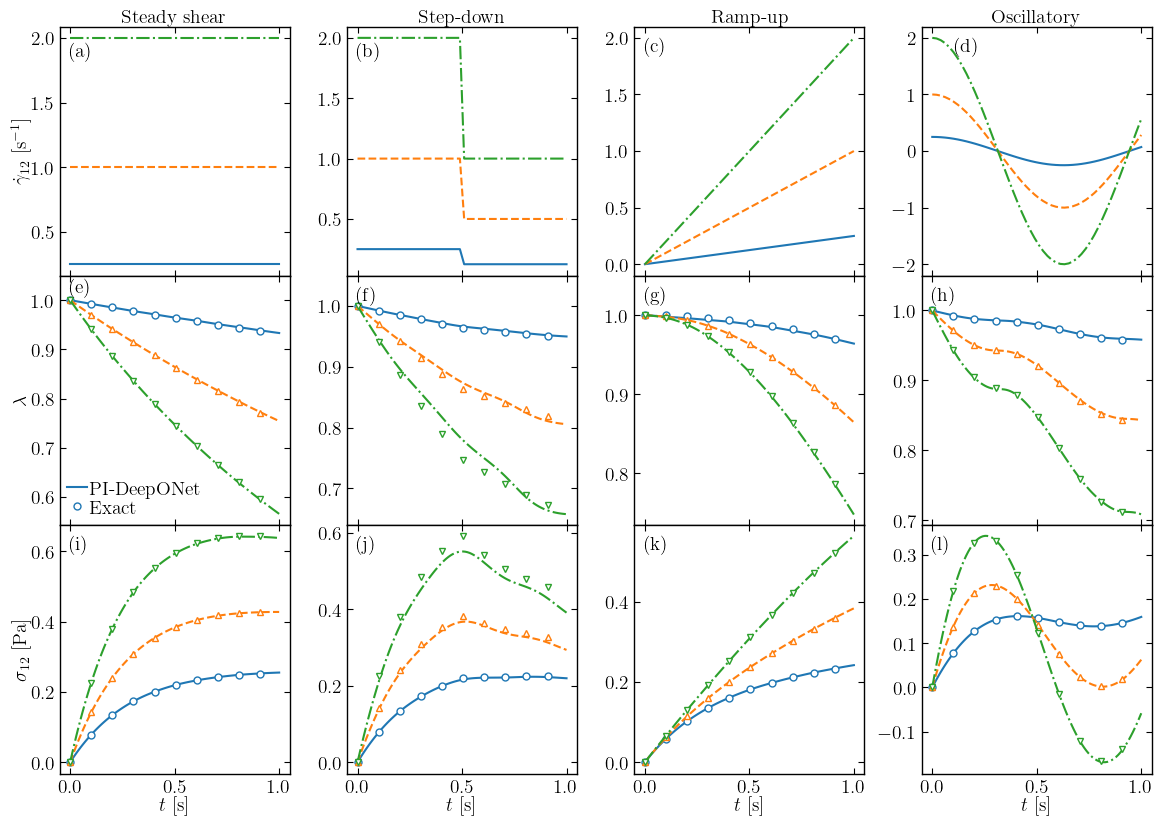

In [15]:
gdot_list = [0.25,1.0,2.0]
ls = ['-','--','-.']
symbol=['o','^','v','d']
c=['#1f77b4','#ff7f0e','#2ca02c']
t = onp.linspace(0,tmax,m)
n1=10
P_test = 100
loc_x = [0.04,0.04,0.04,0.14,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04]
loc_y = [0.9,0.9,0.92,0.92,0.95,0.92,0.92,0.92,0.92,0.92,0.92,0.92]
index = [r'(a)',r'(b)',r'(c)',r'(d)',r'(e)',r'(f)',r'(g)',r'(h)',r'(i)',r'(j)',r'(k)',r'(l)']
fig, axs = plt.subplots(3,4,figsize=(12,9), sharex=True)
ax = axs.flat

for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_steadyshear_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[0].plot(t, u_test[0,0:m],c=c[i],ls=ls[i])
    ax[0+4].plot(x_test,s_pred[:,0],c=c[i],lw=lw,ls=ls[i],label=r'PI-DeepONet')
    ax[0+4].plot(x_test[::n1],s_test[::n1,0],symbol[i],mfc='w',c=c[i],label=r'Exact')
    ax[0+8].plot(x_test,s_pred[:,1],c=c[i],lw=lw,ls=ls[i])
    ax[0+8].plot(x_test[::n1],s_test[::n1,1],symbol[i],mfc='w',c=c[i])
    ax[0+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[0+4].set_ylim([1.05)


for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_oscillatory_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[3].plot(t, u_test[0,0:m],c=c[i],ls=ls[i])
    ax[3+4].plot(x_test,s_pred[:,0],c=c[i],lw=lw,ls=ls[i])
    ax[3+4].plot(x_test[::n1],s_test[::n1,0],symbol[i],mfc='w',c=c[i])
    ax[3+8].plot(x_test,s_pred[:,1],c=c[i],lw=lw,ls=ls[i])
    ax[3+8].plot(x_test[::n1],s_test[::n1,1],symbol[i],mfc='w',c=c[i])
    ax[3+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[3+4].set_ylim(top=1.05)

for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_rampup_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[2].plot(t, u_test[0,0:m],c=c[i],ls=ls[i])
    ax[2+4].plot(x_test,s_pred[:,0],c=c[i],lw=lw,ls=ls[i])
    ax[2+4].plot(x_test[::n1],s_test[::n1,0],symbol[i],mfc='w',c=c[i])
    ax[2+8].plot(x_test,s_pred[:,1],c=c[i],lw=lw,ls=ls[i])
    ax[2+8].plot(x_test[::n1],s_test[::n1,1],symbol[i],mfc='w',c=c[i])
    ax[2+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[2+4].set_ylim(top=1.05)
    
for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_piecewise_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[1].plot(t, u_test[0,0:m],c=c[i],ls=ls[i])
    ax[1+4].plot(x_test,s_pred[:,0],c=c[i],lw=lw,ls=ls[i])
    ax[1+4].plot(x_test[::n1],s_test[::n1,0],symbol[i],mfc='w',c=c[i])
    ax[1+8].plot(x_test,s_pred[:,1],c=c[i],lw=lw,ls=ls[i])
    ax[1+8].plot(x_test[::n1],s_test[::n1,1],symbol[i],mfc='w',c=c[i])
    ax[1+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[1+4].set_ylim(top=1.05)
    
for i in range(3):
    for j in range(4):
        ax[4*i+j].minorticks_off()
        ax[4*i+j].tick_params(axis='both',which='both',direction='in')
        ax[4*i+j].text(loc_x[4*i+j],loc_y[4*i+j], index[4*i+j], ha='left',fontdict=font, transform=ax[4*i+j].transAxes)
for j in range(4):
    ax[4+j].set_ylim(top=1.05)
ax[0].set_ylabel(r'$\dot{\gamma}_{12}$ [s$^{-1}$]',labelpad=0)
ax[4].set_ylabel(r'$\lambda$',labelpad=0)
ax[8].set_ylabel(r'$\sigma_{12}$ [Pa]',labelpad=0)

handles, labels = ax[4].get_legend_handles_labels()
ax[4].legend(handles[:2],labels[:2],loc='lower left',bbox_to_anchor=(0,0),fontsize=f1,ncol=1)

title = [r'Steady shear',r'Step-down',r'Ramp-up',r'Oscillatory']
for j in range(4):
    ax[j].set_title(title[j],fontdict=font)
    
fig.subplots_adjust(left=0.04, bottom=0.12, right=0.95, top=0.95, wspace=0.25, hspace=0.0)
fig.savefig('tevp_deeponet_fig1.png',dpi=600, transparent=False)
plt.show()

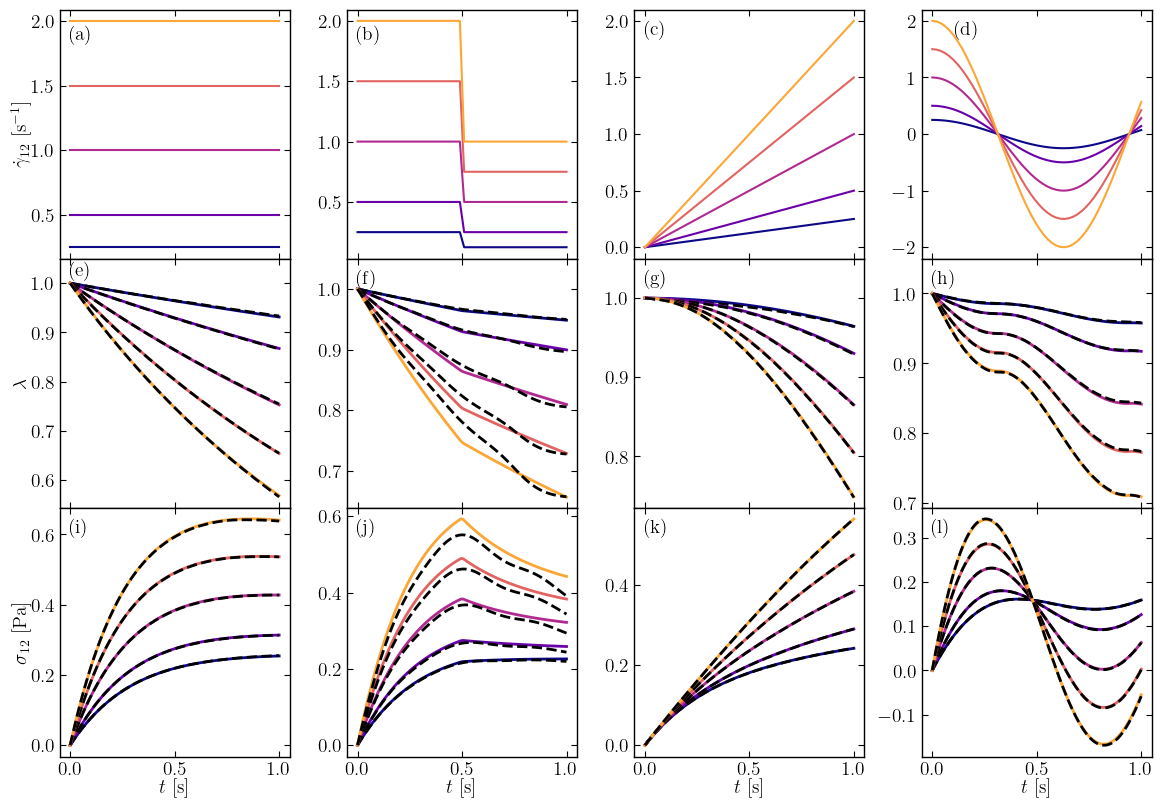

In [27]:
gdot_list = [0.25,0.5,1.0,1.5,2.0]
t = onp.linspace(0,tmax,m)
P_test = 100
loc_x = [0.04,0.04,0.04,0.14,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.04]
loc_y = [0.9,0.9,0.92,0.92,0.95,0.92,0.92,0.92,0.92,0.92,0.92,0.92]
index = [r'(a)',r'(b)',r'(c)',r'(d)',r'(e)',r'(f)',r'(g)',r'(h)',r'(i)',r'(j)',r'(k)',r'(l)']
fig, axs = plt.subplots(3,4,figsize=(12,9), sharex=True)
ax = axs.flat

for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_steadyshear_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[0].plot(t, u_test[0,0:m],c=symcolor)
    ax[0+4].plot(x_test,s_test[:,0],c=symcolor,lw=2)
    ax[0+4].plot(x_test,s_pred[:,0],'k--',lw=2)
    ax[0+8].plot(x_test,s_test[:,1],c=symcolor,lw=2)
    ax[0+8].plot(x_test,s_pred[:,1],'k--',lw=2)
    ax[0+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[0+4].set_ylim([1.05)


for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_oscillatory_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[3].plot(t, u_test[0,0:m],c=symcolor)
    ax[3+4].plot(x_test,s_test[:,0],c=symcolor,lw=2)
    ax[3+4].plot(x_test,s_pred[:,0],'k--',lw=2)
    ax[3+8].plot(x_test,s_test[:,1],c=symcolor,lw=2)
    ax[3+8].plot(x_test,s_pred[:,1],'k--',lw=2)
    ax[3+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[3+4].set_ylim(top=1.05)

for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_rampup_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[2].plot(t, u_test[0,0:m],c=symcolor)
    ax[2+4].plot(x_test,s_test[:,0],c=symcolor,lw=2)
    ax[2+4].plot(x_test,s_pred[:,0],'k--',lw=2)
    ax[2+8].plot(x_test,s_test[:,1],c=symcolor,lw=2)
    ax[2+8].plot(x_test,s_pred[:,1],'k--',lw=2)
    ax[2+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[2+4].set_ylim(top=1.05)
    
for i in range(len(gdot_list)):
    gdot = gdot_list[i]
    u_test, x_test, s_test =  generate_piecewise_data(m, P_test)
    s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
    symcolor = scalarMap.to_rgba(values[i])
    ax[1].plot(t, u_test[0,0:m],c=symcolor)
    ax[1+4].plot(x_test,s_test[:,0],c=symcolor,lw=2)
    ax[1+4].plot(x_test,s_pred[:,0],'k--',lw=2)
    ax[1+8].plot(x_test,s_test[:,1],c=symcolor,lw=2)
    ax[1+8].plot(x_test,s_pred[:,1],'k--',lw=2)
    ax[1+8].set_xlabel('$t$ [s]',labelpad=0)
    #ax[1+4].set_ylim(top=1.05)
    
for i in range(3):
    for j in range(4):
        ax[4*i+j].minorticks_off()
        ax[4*i+j].tick_params(axis='both',which='both',direction='in')
        ax[4*i+j].text(loc_x[4*i+j],loc_y[4*i+j], index[4*i+j], ha='left',fontdict=font, transform=ax[4*i+j].transAxes)
for j in range(4):
    ax[4+j].set_ylim(top=1.05)
ax[0].set_ylabel(r'$\dot{\gamma}_{12}$ [s$^{-1}$]',labelpad=0)
ax[4].set_ylabel(r'$\lambda$',labelpad=0)
ax[8].set_ylabel(r'$\sigma_{12}$ [Pa]',labelpad=0)
fig.subplots_adjust(left=0.04, bottom=0.12, right=0.95, top=0.95, wspace=0.25, hspace=0.0)
fig.savefig('tevp_deeponet_fig1.png',dpi=600, transparent=False)
plt.show()